In [61]:
import numpy as np
import pandas as pd
import tensorflow as tf 
import scipy.sparse as sp
from recommenders.evaluation.python_evaluation import (
    map_at_k,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
)

import LightGCN
from utils import get_top_k_scored_items, nCoreReduction, user_fixed_train_test_split

import matplotlib.pyplot as plt 

import importlib 

import ActiveLearner

# disable the SettingWithCopyWarning
pd.options.mode.chained_assignment = None

## Load data

In [62]:
data_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.data"
data_columns = ['user_id', 'item_id', 'rating', 'timestamp']

user_url = "https://files.grouplens.org/datasets/movielens/ml-100k/u.user"
user_columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

In [63]:
data_df = pd.read_csv(data_url, sep='\t', names=data_columns, header=None)
user_df = pd.read_csv(user_url, sep='|', names=user_columns, header=None)

In [64]:
# shuffle data_df
data_df = data_df.sample(frac=1, random_state=42).reset_index(drop=True)

## Convert to implicit feedback

**Note**: For MovieLens 100k dataset, we are converting a rating in the range [1, 5] to an implicit feedback of 1 so that we still have a significant number of positive samples in the dataset. For MovieLens 1M, we could do [3, 5] instead.

We might not need this.

In [ ]:
# data_df['rating'] = (data_df['rating'] >= 1).astype(int)

## Dimensionality reduction

Only keep:
- users that provided at least 5 ratings
- items that received at least 5 ratings

In [65]:
ncore_data_df = nCoreReduction(data_df)

In [66]:
print(f"The original data frame shape: {data_df.shape}")
print(f"  - # users: {data_df['user_id'].nunique()}")
print(f"  - # items: {data_df['item_id'].nunique()}")
print('\n')

print(f"The filtered data frame shape: {ncore_data_df.shape}")
print(f"  - # users: {ncore_data_df['user_id'].nunique()}")
print(f"  - # items: {ncore_data_df['item_id'].nunique()}")

The original data frame shape: (100000, 4)
  - # users: 943
  - # items: 1682


The filtered data frame shape: (99032, 4)
  - # users: 943
  - # items: 1298


## Convert id to inner id

In [67]:
unique_users = ncore_data_df['user_id'].unique()
user_id_to_iid = {id: iid for iid, id in enumerate(unique_users)}
user_iid_to_id = {iid: id for iid, id in enumerate(unique_users)}

unique_items = ncore_data_df['item_id'].unique()
item_id_to_iid = {id: iid for iid, id in enumerate(unique_items)}
item_iid_to_id = {iid: id for iid, id in enumerate(unique_items)}

In [68]:
n_users = unique_users.shape[0]
n_items = unique_items.shape[0]

In [69]:
ncore_data_df['user_iid'] = ncore_data_df['user_id'].map(user_id_to_iid)
ncore_data_df['item_iid'] = ncore_data_df['item_id'].map(item_id_to_iid)

# apply to `user_df`` as well
user_df['user_iid'] = user_df['user_id'].map(user_id_to_iid)

In [70]:
iid_to_gender = dict(zip(user_df['user_iid'], user_df['gender']))

## Train test split (user-fixed)

In [71]:
train_df, test_df = user_fixed_train_test_split(ncore_data_df, test_size=0.2, random_state=42)

## Train the model

In [13]:
hparams = {
    'epochs': 50,
    'learning_rate': 0.001,
    'embed_size': 32,
    'batch_size': 1024,
    'n_layers': 3,
    'decay': 0.0001,
    'eval_epoch': -1,
    'top_k': 10,
}

In [ ]:
importlib.reload(LightGCN)

In [14]:
model = LightGCN.LightGCNRecommender(hparams, train_df, test_df, n_users, n_items, seed=42)

In [15]:
model.fit()

KeyboardInterrupt: 

## Evaluation

In [ ]:
topk_scores = model.recommend_k_items(test_df, top_k=10, remove_seen=True)
topk_scores.head()

In [ ]:
col_user = 'user_iid'
col_item = 'item_iid'
col_prediction = 'rating_estimate'

In [ ]:
eval_map = map_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)
eval_ndcg = ndcg_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)
eval_precision = precision_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)
eval_recall = recall_at_k(test_df, topk_scores, k=10, col_user=col_user, col_item=col_item, col_prediction=col_prediction)

In [ ]:
print(
    f"MAP@K:\t{eval_precision:.3f}",
    f"NDCG@K:\t{eval_ndcg:.3f}",
    f"Precision@K:\t{eval_precision:.3f}",
    f"Recall@K:\t{eval_recall:.3f}",
    sep="\n"
)

## Active Learning

In [21]:
importlib.reload(ActiveLearner)
importlib.reload(LightGCN)

<module 'LightGCN' from '/Users/sipei/Tufts/Research/AL/LightGCN.py'>

In [ ]:
hparams = {
    'epochs': 50,
    'learning_rate': 0.001,
    'embed_size': 32,
    'batch_size': 1024,
    'n_layers': 3,
    'decay': 0.0001,
    'eval_epoch': -1,
    'top_k': 10,
}

epochs = 20

In [ ]:
hparams = {
    'epochs': 50,
    'learning_rate': 0.005,
    'embed_size': 64,
    'batch_size': 1024,
    'n_layers': 3,
    'decay': 0.0001,
    'eval_epoch': -1,
    'top_k': 10,
}

epochs = 20

In [24]:
al = ActiveLearner.RatingBasedActiveLearner(
    strategy = 'MaxRating', 
    model = LightGCN.LightGCNRecommender,
    model_hparams=hparams,
    tr_df=train_df[['user_iid', 'item_iid', 'rating']],
    te_df=test_df[['user_iid', 'item_iid', 'rating']],
    n_users=n_users,
    n_items=n_items,
    q=10,
    seed=42,
)

In [25]:
results_lst = []
print('Starting the Active Learning process')
for i in range(epochs):
    print('------------------------------------\n')
    print(f'Epoch: {i+1}')
    print(f'# of ratings elicited: {al.kn_df.shape[0]}')
    print(f'Percentage of ratings elicited: {100*(al.kn_df.shape[0]/train_df.shape[0]):.2f}%')
    results = al.run_epoch(iid_to_gender)
    results_lst.append(results)

Starting the Active Learning process
------------------------------------

Epoch: 1
# of ratings elicited: 3939
Percentage of ratings elicited: 5.00%
------------------------------------

Epoch: 2
# of ratings elicited: 13369
Percentage of ratings elicited: 16.96%
------------------------------------

Epoch: 3
# of ratings elicited: 22275
Percentage of ratings elicited: 28.25%
------------------------------------

Epoch: 4
# of ratings elicited: 29317
Percentage of ratings elicited: 37.18%
------------------------------------

Epoch: 5
# of ratings elicited: 35181
Percentage of ratings elicited: 44.62%
------------------------------------

Epoch: 6
# of ratings elicited: 40175
Percentage of ratings elicited: 50.95%
------------------------------------

Epoch: 7
# of ratings elicited: 44494
Percentage of ratings elicited: 56.43%
------------------------------------

Epoch: 8
# of ratings elicited: 48415
Percentage of ratings elicited: 61.40%
------------------------------------

Epoch: 

In [26]:
precision_results = np.array([r['precision'] for r in results_lst])

In [27]:
recall_results = np.array([r['recall'] for r in results_lst])

In [28]:
ndcg_results = np.array([r['ndcg'] for r in results_lst])

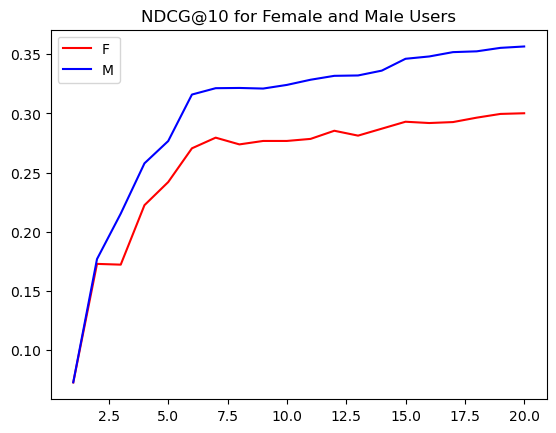

In [29]:
plt.plot(np.arange(1,epochs+1), ndcg_results[:, 0], label='F', c='r')
plt.plot(np.arange(1,epochs+1), ndcg_results[:, 1], label='M', c='b')
plt.title("NDCG@10 for Female and Male Users")
plt.legend()
plt.show()

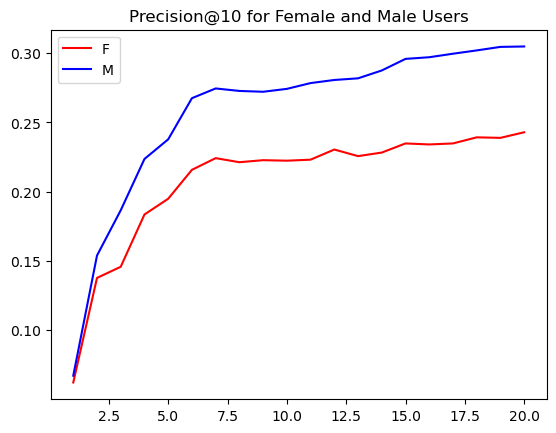

In [30]:
plt.plot(np.arange(1,epochs+1), precision_results[:, 0], label='F', c='r')
plt.plot(np.arange(1,epochs+1), precision_results[:, 1], label='M', c='b')
plt.title("Precision@10 for Female and Male Users")
plt.legend()
plt.show()

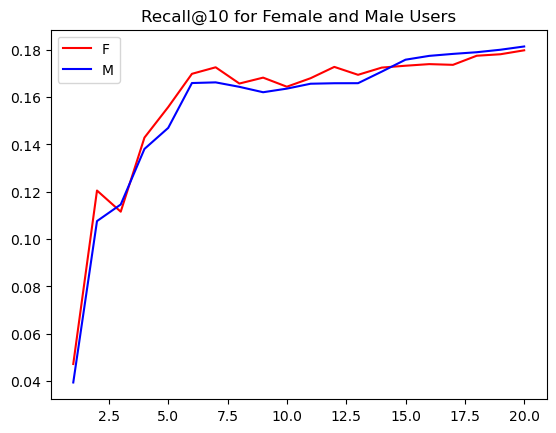

In [31]:
plt.plot(np.arange(1,epochs+1), recall_results[:, 0], label='F', c='r')
plt.plot(np.arange(1,epochs+1), recall_results[:, 1], label='M', c='b')
plt.title("Recall@10 for Female and Male Users")
plt.legend()
plt.show()